In [38]:
import numpy as np
import pandas as pd
import re
import collections
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow import keras
from keras import layers, Model, Input
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')
print(f'NumPy      {np.__version__}')


TensorFlow 2.20.0
NumPy      2.0.2


# 1. Preprocesamiento de datos

# 1.1. Inspección de los datos

El primer paso a realizar dentro de un entrenamiento e implementación de un modelo de Red Neuronal es extraer aquellos datos que se van a emplear dentro del entrenamiento del modelo.

In [39]:
df = pd.read_csv("news_dataset.csv", quotechar='"')

In [40]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [41]:
df.shape

(120000, 3)

In [42]:
df['Class Index'].value_counts()

,count
Class Index,
3,30000
4,30000
2,30000
1,30000


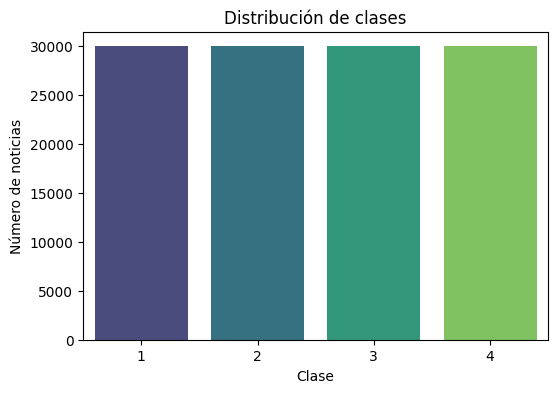

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class Index', data=df, palette='viridis')
plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Número de noticias')
plt.show()

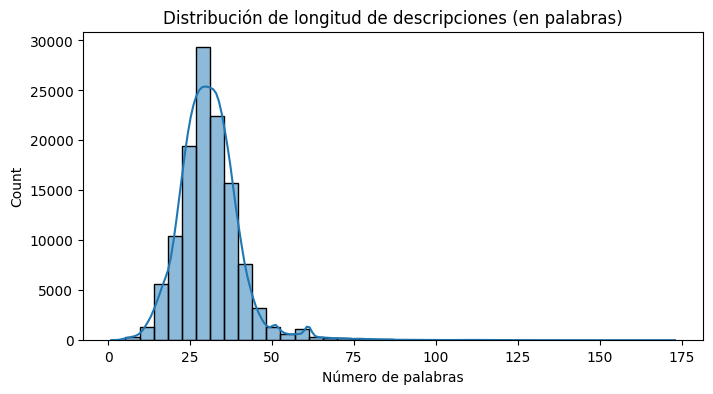

count    120000.000000
mean         31.060508
std           9.760460
min           1.000000
25%          25.000000
50%          30.000000
75%          36.000000
max         173.000000
Name: longitud, dtype: float64


In [44]:
df['longitud'] = df['Description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
sns.histplot(df['longitud'], bins=40, kde=True)
plt.title('Distribución de longitud de descripciones (en palabras)')
plt.xlabel('Número de palabras')
plt.show()

print(df['longitud'].describe())

In [45]:
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'\[.*?\]\(.*?\)', '', texto)
    texto = re.sub(r'http\S+|www\.\S+', '', texto)
    texto = re.sub(r'<[^>]+>', ' ', texto)
    texto = texto.replace('\\', ' ')
    texto = re.sub(r'^(reuters|ap|afp)\s*-\s*', '', texto)
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)
    texto = re.sub(r'\b\w\b', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto



# Guardar en columnas nuevas del DataFrame
df['Description_clean'] = df['Description'].apply(limpiar_texto)
df['Title_clean'] = df['Title'].apply(limpiar_texto)

# Combinar título y descripción
df['Texto_completo'] = df['Title_clean'] + ' ' + df['Description_clean']

df[['Title_clean', 'Description_clean', 'Texto_completo']].head(5)

,Title_clean,Description_clean,Texto_completo
0,wall st bears claw back into the black reuters,short sellers wall street dwindling band of ul...,wall st bears claw back into the black reuters...
1,carlyle looks toward commercial aerospace reuters,private investment firm carlyle group which ha...,carlyle looks toward commercial aerospace reut...
2,oil and economy cloud stocks outlook reuters,soaring crude prices plus worries about the ec...,oil and economy cloud stocks outlook reuters s...
3,iraq halts oil exports from main southern pipe...,authorities have halted oil export flows from ...,iraq halts oil exports from main southern pipe...
4,oil prices soar to all time record posing new ...,tearaway world oil prices toppling records and...,oil prices soar to all time record posing new ...


In [46]:
stopwords = {
    'the', 'to', 'of', 'in', 'and', 'on', 'for', 'that', 'with', 'as',
    'at', 'is', 'by', 'it', 'be', 'are', 'was', 'were', 'from', 'an',
    'this', 'have', 'has', 'had', 'but', 'not', 'they', 'he', 'she',
    'we', 'you', 'his', 'her', 'their', 'its', 'our', 'or', 'will',
    'been', 'about', 'which', 'who', 'after', 'also', 'more', 'than',
    'up', 'said', 'would', 'could', 'into', 'over', 'do', 'did', 'out',
    'no', 'if', 'when', 'there', 'all', 'can', 'one', 'two', 'so', 'what',
    'lt', 'gt', 'quot', 'amp',          # restos de HTML
    'reuters', 'ap', 'afp',             # agencias
    'monday', 'tuesday', 'wednesday',   # días
    'thursday', 'friday', 'saturday', 'sunday',
    'us', 'new', 'first', 'year',       # palabras poco informativas
}

def tokenizar(texto):
    return texto.split()

tokens_completo = [tokenizar(t) for t in df['Texto_completo']]

# Filtrar stopwords de los tokens
tokens_completo = [
    [token for token in doc if token not in stopwords]
    for doc in tokens_completo
]

print('ORIGINAL:')
print((df.loc[0]['Title'] + ' ' + df.loc[0]['Description'])[:200])
print()
print('LIMPIO:')
print(df.loc[0]['Texto_completo'][:200])
print()
print('TOKENS (primeros 15):')
print(tokens_completo[0][:15])

ORIGINAL:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

LIMPIO:
wall st bears claw back into the black reuters short sellers wall street dwindling band of ultra cynics are seeing green again

TOKENS (primeros 15):
['wall', 'st', 'bears', 'claw', 'back', 'black', 'short', 'sellers', 'wall', 'street', 'dwindling', 'band', 'ultra', 'cynics', 'seeing']


In [47]:
MIN_FREQ = 5

# Contar frecuencias en el corpus
freq = collections.Counter(token for doc in tokens_completo for token in doc)

print(f'Palabras únicas (sin filtrar): {len(freq):,}')
print(f'Palabras con freq >= {MIN_FREQ}: {sum(1 for f in freq.values() if f >= MIN_FREQ):,}')
print()

# Construir vocabulario: palabra → ID
word2idx = {'<PAD>': 0, '<UNK>': 1}
for palabra, conteo in freq.most_common():
    if conteo >= MIN_FREQ:
        word2idx[palabra] = len(word2idx)

idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f'Tamaño final del vocabulario: {VOCAB_SIZE:,}')
print(f'  (incluye <PAD>=0 y <UNK>=1)')
print()
print('Top 15 palabras más frecuentes:')
for palabra, conteo in freq.most_common(15):
    print(f'  {palabra:<15} freq={conteo:>5}  ID={word2idx.get(palabra, "?")}')

Palabras únicas (sin filtrar): 61,648
Palabras con freq >= 5: 26,719

Tamaño final del vocabulario: 26,721
  (incluye <PAD>=0 y <UNK>=1)

Top 15 palabras más frecuentes:
  world           freq= 8634  ID=2
  company         freq= 7656  ID=3
  oil             freq= 7564  ID=4
  against         freq= 6899  ID=5
  inc             freq= 6853  ID=6
  last            freq= 6548  ID=7
  iraq            freq= 6335  ID=8
  york            freq= 6268  ID=9
  yesterday       freq= 6099  ID=10
  three           freq= 6034  ID=11
  president       freq= 5994  ID=12
  microsoft       freq= 5935  ID=13
  million         freq= 5812  ID=14
  game            freq= 5774  ID=15
  week            freq= 5654  ID=16


In [48]:
def texto_a_ids(tokens_doc, vocabulario):
    """Convierte una lista de tokens en una lista de IDs enteros."""
    UNK_ID = vocabulario.get('<UNK>', 1)
    return [vocabulario.get(token, UNK_ID) for token in tokens_doc]

# Convertir todos los textos a secuencias de IDs
secuencias = [texto_a_ids(doc, word2idx) for doc in tokens_completo]

# Verificar
print('Tokens:  ', tokens_completo[0][:8])
print('IDs:     ', secuencias[0][:8])

Tokens:   ['wall', 'st', 'bears', 'claw', 'back', 'black', 'short', 'sellers']
IDs:      [339, 266, 1495, 13816, 33, 721, 627, 7775]


In [49]:
y = df['Class Index'].values - 1
NUM_CLASSES = 4

sec_temp, secuencias_test, y_temp, y_test_raw = train_test_split(
    secuencias, y, test_size=0.1, random_state=42, stratify=y
)

sec_train, sec_val, y_tr, y_val = train_test_split(
    sec_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp
)

longitudes = [len(s) for s in sec_train]
MAX_LEN = int(np.percentile(longitudes, 90))  # cubre el 90% de los docs
MAX_LEN = min(MAX_LEN, 200)  # tope máximo para velocidad

print(f'MAX_LEN elegido: {MAX_LEN}')
print(f'  Media de tokens por documento: {np.mean(longitudes):.0f}')
print(f'  Percentil 50: {np.percentile(longitudes, 50):.0f}')
print(f'  Percentil 90: {np.percentile(longitudes, 90):.0f}')
print(f'  Máximo:       {max(longitudes)}')

X_tr  = pad_sequences(sec_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val = pad_sequences(sec_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_te  = pad_sequences(secuencias_test, maxlen=MAX_LEN, padding='post', truncating='post')

y_tr_cat  = to_categorical(y_tr,        NUM_CLASSES)
y_val_cat = to_categorical(y_val,       NUM_CLASSES)
y_te_cat  = to_categorical(y_test_raw,  NUM_CLASSES)

print(f'\nShapes resultantes:')
print(f'  X_tr:  {X_tr.shape}   y_tr:  {y_tr_cat.shape}')
print(f'  X_val: {X_val.shape}  y_val: {y_val_cat.shape}')
print(f'  X_te:  {X_te.shape}   y_te:  {y_te_cat.shape}')

MAX_LEN elegido: 31
  Media de tokens por documento: 24
  Percentil 50: 24
  Percentil 90: 31
  Máximo:       105

Shapes resultantes:
  X_tr:  (96001, 31)   y_tr:  (96001, 4)
  X_val: (11999, 31)  y_val: (11999, 4)
  X_te:  (12000, 31)   y_te:  (12000, 4)


In [50]:
dim752_v2 = np.load('dim752_v2_loss.npy')
vocab_size, emb_dim = dim752_v2.shape
print(f"Dimensiones de la matriz cargada: {dim752_v2.shape}")

Dimensiones de la matriz cargada: (12,)


In [51]:
def construir_modelo(arq, emb_matrix, num_capas, lr, max_len, num_clases):
    vocab_size, emb_dim = emb_matrix.shape
    print(f'vocab_size={vocab_size}, emb_dim={emb_dim}')

    UNITS = 64  # unidades de la capa recurrente (reducido para velocidad)

    # Seleccionar tipo de capa recurrente
    RecurrentLayer = layers.LSTM if arq == 'LSTM' else layers.GRU

    modelo = keras.Sequential(name=f'{arq}_{num_capas}L_lr{lr}')

    # Capa Embedding con pesos pre-entrenados
    modelo.add(layers.Embedding(
        input_dim=vocab_size, output_dim=emb_dim,
        weights=[emb_matrix], trainable=False,
        input_length=max_len, mask_zero=True
    ))

    # Capas recurrentes dinámicas mediante bucle for
    for i in range(num_capas):
        # Si no es la última capa, debe retornar la secuencia completa
        if i < num_capas - 1:
            modelo.add(RecurrentLayer(UNITS, return_sequences=True))
        else:
            # La última capa solo devuelve el estado final
            modelo.add(RecurrentLayer(UNITS))

    # Capas densas de clasificación
    modelo.add(layers.Dense(64, activation='relu'))
    modelo.add(layers.Dropout(0.3))
    modelo.add(layers.Dense(num_clases, activation='softmax'))

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo


In [52]:
# Configuraciones a probar
CONFIGS = [
    ('LSTM', dim752_v2,  1, 0.001, f'LSTM_d64_1L_lr001'),
    ('GRU',  dim752_v2,  1, 0.001, f'GRU_d64_1L_lr001'),
    ('LSTM', dim752_v2, 1, 0.001, f'LSTM_d128_1L_lr001'),
    ('LSTM', dim752_v2,  2, 0.001, f'LSTM_d64_2L_lr001'),
    ('LSTM', dim752_v2,  1, 0.003, f'LSTM_d64_1L_lr003'),
    ('GRU',  dim752_v2, 2, 0.003, f'GRU_d128_2L_lr003'),
]

EPOCHS_CLF = 8
BATCH_CLF  = 64

resultados = {}
mejor_acc  = 0
mejor_nombre = ''
mejor_modelo = None

for arch, emb_mat, n_layers, lr, nombre in CONFIGS:
    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre}')
    print(f'  arch={arch}, emb_dim={emb_mat.shape[1]}, capas={n_layers}, lr={lr}')

    modelo = construir_modelo(arch, emb_mat, n_layers, lr, MAX_LEN, NUM_CLASSES)

    hist = modelo.fit(
        X_tr, y_tr_cat,
        validation_data=(X_val, y_val_cat),
        epochs=EPOCHS_CLF, batch_size=BATCH_CLF, verbose=0
    )

    val_acc_final = hist.history['val_accuracy'][-1]
    print(f'  → val_accuracy final: {val_acc_final:.4f}')

    resultados[nombre] = hist.history

    if val_acc_final > mejor_acc:
        mejor_acc = val_acc_final
        mejor_nombre = nombre
        mejor_modelo = modelo

print(f'\n{"="*60}')
print(f'Mejor modelo: {mejor_nombre} (val_acc={mejor_acc:.4f})')



Entrenando: LSTM_d64_1L_lr001


IndexError: tuple index out of range

In [ ]:
# Gráficas de accuracy train vs val para cada configuración
n_configs = len(resultados)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, (nombre, hist) in enumerate(resultados.items()):
    ax = axes[idx]
    ax.plot(hist['accuracy'],     label='Train', linewidth=2)
    ax.plot(hist['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(nombre, fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Ocultar ejes sobrantes si hay menos de 6 configs
for idx in range(n_configs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Comparación de configuraciones — Accuracy train vs validación', fontsize=13)
plt.tight_layout()
plt.show()
